In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Thiết lập style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# 1. Nạp dữ liệu từ thư mục interim
data_path = "../data/interim/extracted_data.csv"
print("Đang nạp dữ liệu từ local...")
df = pd.read_csv(data_path)
print(f"Kích thước bộ dữ liệu thô: {df.shape}")
df.head(3)

Đang nạp dữ liệu từ local...
Kích thước bộ dữ liệu thô: (7043, 20)


,ID,Churn,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaymentMethod,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,tenure_group,service_diversity,monthly_charges_ratio,is_paperless_electronic
0,0002-ORFBO,0,0,1,No,9,12,Mailed check,1,65.6,593.30,DSL,0,1,0,1,0-12 months,2,1.012944,0
1,0003-MKNFE,0,0,0,No,9,1,Mailed check,0,59.9,542.40,DSL,0,0,0,0,0-12 months,0,0.924930,0
2,0004-TLHLJ,1,0,0,No,4,1,Electronic check,1,73.9,280.85,Fiber optic,0,0,1,0,0-12 months,1,1.141107,0


Đang tiến hành chuẩn hóa DataFrame...
Đã chuẩn hóa xong DataFrame! Tất cả các cell sau có thể dùng tên mới.
Đang tiến hành vẽ Bar Chart chuẩn LaTeX...


C:\Users\HGB\AppData\Local\Temp\ipykernel_9240\876450176.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(labels, rotation=45, ha='right')
C:\Users\HGB\AppData\Local\Temp\ipykernel_9240\876450176.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(labels, rotation=45, ha='right')
C:\Users\HGB\AppData\Local\Temp\ipykernel_9240\876450176.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(labels, rotation=45, ha='right')


Đã lưu biểu đồ thành công tại: barchart_categorical_variables.png


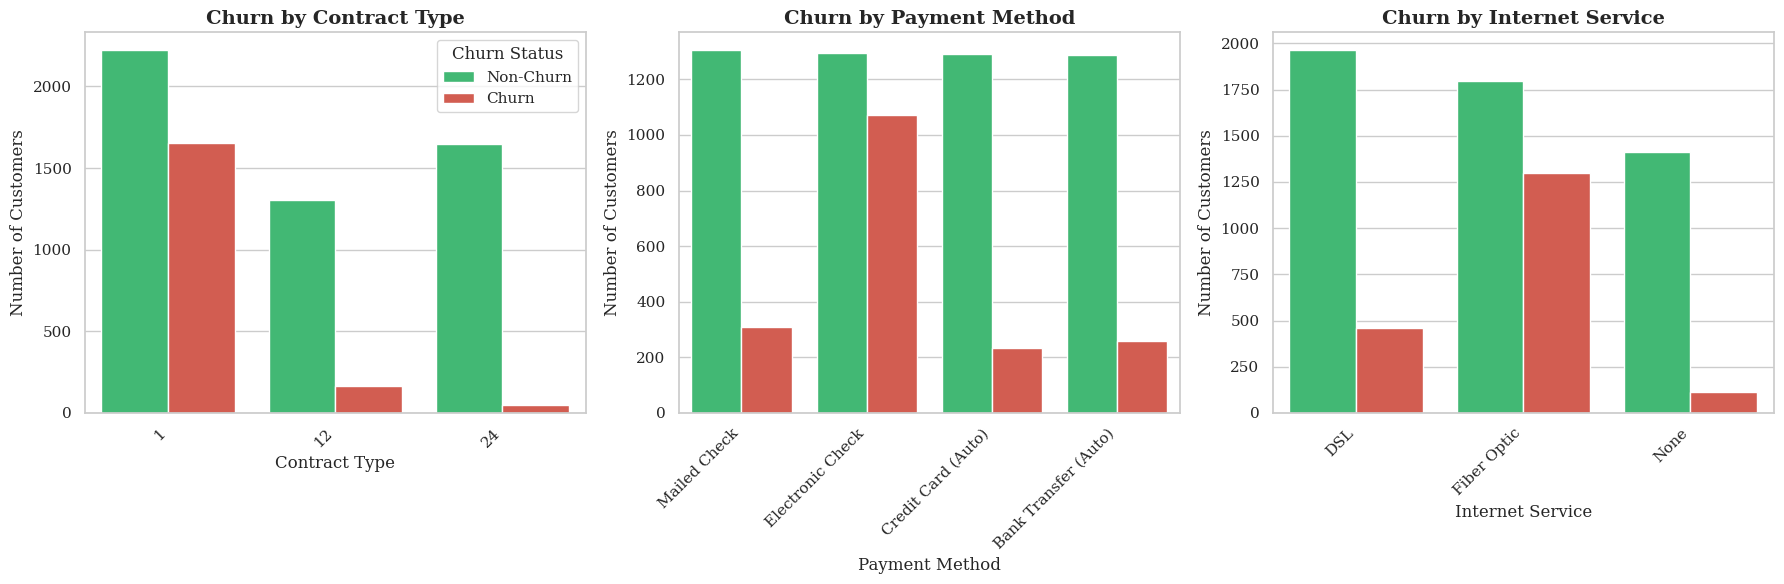

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# 1. CẤU HÌNH ĐỒ THỊ CHUẨN ACADEMIC (LATEX STYLE) CHO TOÀN BỘ NOTEBOOK
# =========================================================================
# Định hình cấu hình font chữ Serif (giống Times New Roman) cho toàn file
plt.rcParams.update({
    "font.family": "serif",
    "text.usetex": False,  # Đổi thành True nếu máy bạn đã cài MiKTeX/TeX Live
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12
})

# =========================================================================
# 2. MAPPING & CHUẨN HÓA DATAFRAME (DÙNG CHO TOÀN BỘ FILE .IPYNB)
# =========================================================================

# Dictionary 1: Đổi tên CỘT (Columns) sang Tiếng Anh học thuật
column_mapping = {
    'Contract': 'Contract Type',
    'PaymentMethod': 'Payment Method',
    'InternetService': 'Internet Service',
    'SeniorCitizen': 'Senior Citizen Status',
    'Partner': 'Partner Status',
    'Tenure': 'Tenure (Months)',
    'PaperlessBilling': 'Paperless Billing',
    'MonthlyCharges': 'Monthly Charges',
    'TotalCharges': 'Total Charges',
    'OnlineSecurity': 'Online Security Opt-in',
    'OnlineBackup': 'Online Backup Opt-in',
    'DeviceProtection': 'Device Protection Opt-in',
    'TechSupport': 'Technical Support Opt-in',
    'service_diversity': 'Service Diversity Score',
    'monthly_charges_ratio': 'Monthly Charges Ratio',
    'is_paperless_electronic': 'Paperless & Auto-Payment Combo'
}

# Dictionary 2: Đổi GIÁ TRỊ (Values) thô bên trong các cột phân loại
value_mapping = {
    'Payment Method': {
        'Credit card (automatic)': 'Credit Card (Auto)',
        'Electronic check': 'Electronic Check',
        'Mailed check': 'Mailed Check',
        'Bank transfer (automatic)': 'Bank Transfer (Auto)' # Bổ sung nếu có
    },
    'Internet Service': {
        'Fiber optic': 'Fiber Optic',
        'DSL': 'DSL',
        'No': 'None'
    },
    'Contract Type': {
        'Month-to-month': 'Month-to-Month',
        'One year': 'One Year',
        'Two year': 'Two Year'
    },
    # Mapping cho biến mục tiêu Churn (để Legend tự động nhận diện chữ thay vì số 0, 1)
    'Churn': {
        1: 'Churn', 
        0: 'Non-Churn',
        'Yes': 'Churn',
        'No': 'Non-Churn'
    }
}

print("Đang tiến hành chuẩn hóa DataFrame...")

# Tiến hành đổi tên cột trực tiếp trên df
df = df.rename(columns=column_mapping)

# Tiến hành thay thế giá trị bên trong các cột theo map đã định nghĩa
for col, mappings in value_mapping.items():
    if col in df.columns:
        df[col] = df[col].replace(mappings)

print("Đã chuẩn hóa xong DataFrame! Tất cả các cell sau có thể dùng tên mới.")

# =========================================================================
# 3. VẼ BIỂU ĐỒ CỘT (BAR CHART) - BÂY GIỜ CODE ĐÃ CỰC KỲ GỌN
# =========================================================================
print("Đang tiến hành vẽ Bar Chart chuẩn LaTeX...")

# Danh sách các biến phân loại cần vẽ (lúc này đã là tên mới sau khi map)
categorical_vars = ['Contract Type', 'Payment Method', 'Internet Service']

# Tạo khung hình (Figure) với 3 subplots (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    # Vẽ trực tiếp, hue='Churn' lúc này đã tự nhận nhãn 'Churn'/'Non-Churn'
    sns.countplot(
        data=df, 
        x=var, 
        hue='Churn', 
        ax=axes[i], 
        palette={'Churn': '#e74c3c', 'Non-Churn': '#2ecc71'} 
    )
    
    # Cấu hình Tiêu đề và Nhãn (Lấy trực tiếp từ tên cột của DataFrame)
    axes[i].set_title(f'Churn by {var}', fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Number of Customers')
    
    # Xoay nhãn trục X 45 độ, căn lề phải để chữ không đè nhau
    axes[i].tick_params(axis='x', rotation=45)
    labels = axes[i].get_xticklabels()
    axes[i].set_xticklabels(labels, rotation=45, ha='right')
    
    # Cấu hình Legend (Chỉ giữ lại ở đồ thị đầu tiên cho gọn)
    if i == 0:
        axes[i].legend(title='Churn Status', loc='upper right')
    else:
        axes[i].get_legend().remove() 

# Tối ưu khoảng cách tránh cắt chữ
plt.tight_layout()

# Lưu hình ảnh độ phân giải cao chuẩn in ấn LaTeX
save_path = 'barchart_categorical_variables.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Đã lưu biểu đồ thành công tại: {save_path}")

# Hiển thị đồ thị
plt.show()

Đang tiến hành vẽ Correlation Heatmap...
Đã lưu biểu đồ thành công tại: heatmap_correlation_matrix.png


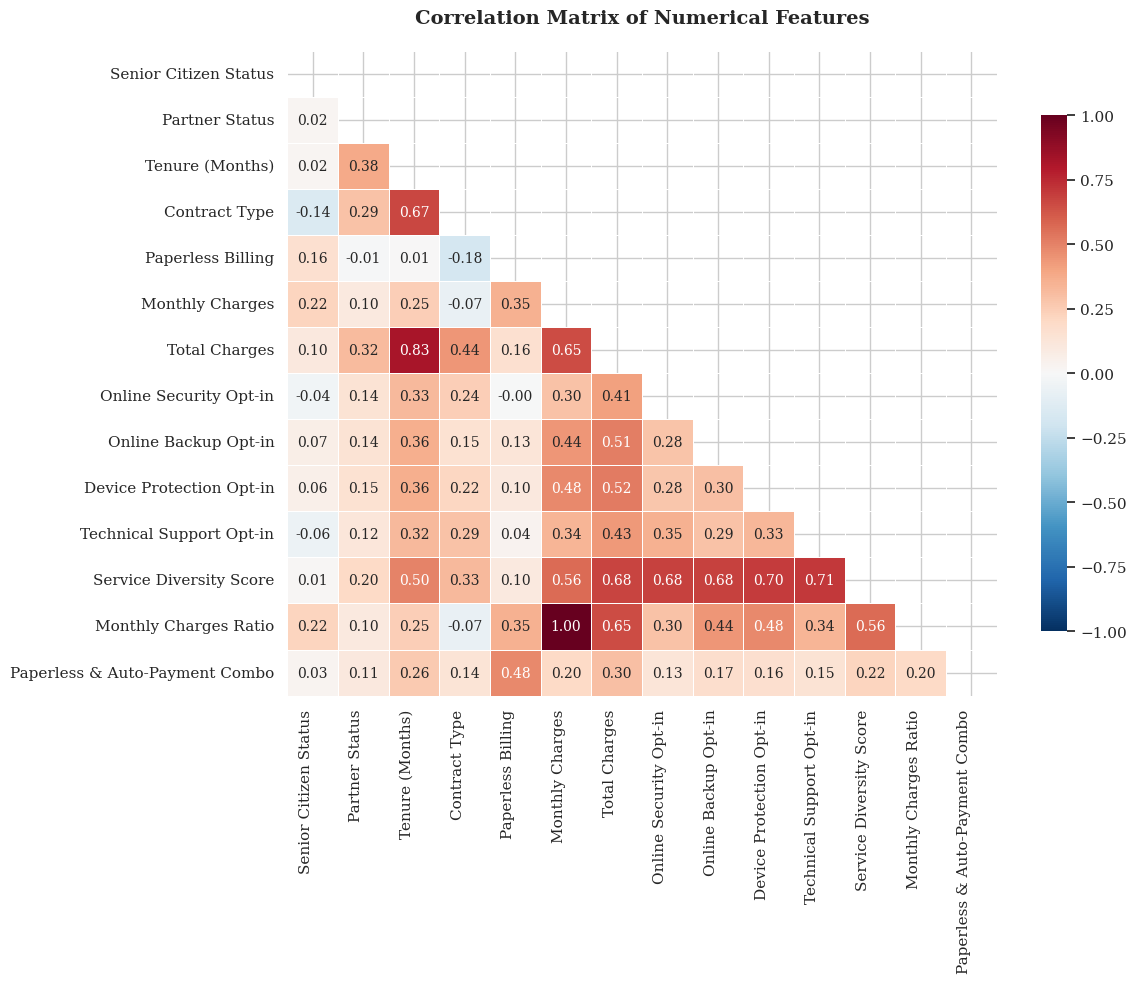

In [14]:
# =========================================================================
# 4. VẼ MA TRẬN TƯƠNG QUAN (CORRELATION HEATMAP) CHO CÁC BIẾN SỐ
# =========================================================================
print("Đang tiến hành vẽ Correlation Heatmap...")

# Tạo khung hình với tỷ lệ cân đối cho ma trận
plt.figure(figsize=(12, 10))

# Lọc các cột định lượng (số nguyên và số thực) để tính tương quan
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[num_cols].corr()

# TẠO MASK: Che đi nửa trên của ma trận và đường chéo chính (giá trị 1)
# Việc này giúp đồ thị không bị lặp lại thông tin và thoáng mắt hơn
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Vẽ Heatmap
ax = sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r",           # Dải màu Đỏ-Xanh dương chuẩn học thuật
    linewidths=0.5, 
    vmin=-1, 
    vmax=1,
    annot_kws={"size": 10},  # Cỡ chữ của các con số bên trong ô
    cbar_kws={"shrink": .8}  # Thu nhỏ thanh colorbar 80% để cân xứng với hình
)

# Cấu hình Tiêu đề bằng Tiếng Anh chuẩn
plt.title("Correlation Matrix of Numerical Features", fontweight='bold', pad=20)

# Xoay nhãn trục X và Y để chữ không đè lên nhau
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)

# Tối ưu layout để tránh bị cắt viền
plt.tight_layout()

# Lưu hình ảnh chuẩn in ấn LaTeX (dpi=300)
save_path = 'heatmap_correlation_matrix.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
print(f"Đã lưu biểu đồ thành công tại: {save_path}")

# Hiển thị đồ thị
plt.show()

Đang tiến hành vẽ Boxplot kiểm tra ngoại lai...
Đã lưu biểu đồ thành công tại: boxplot_outliers.png


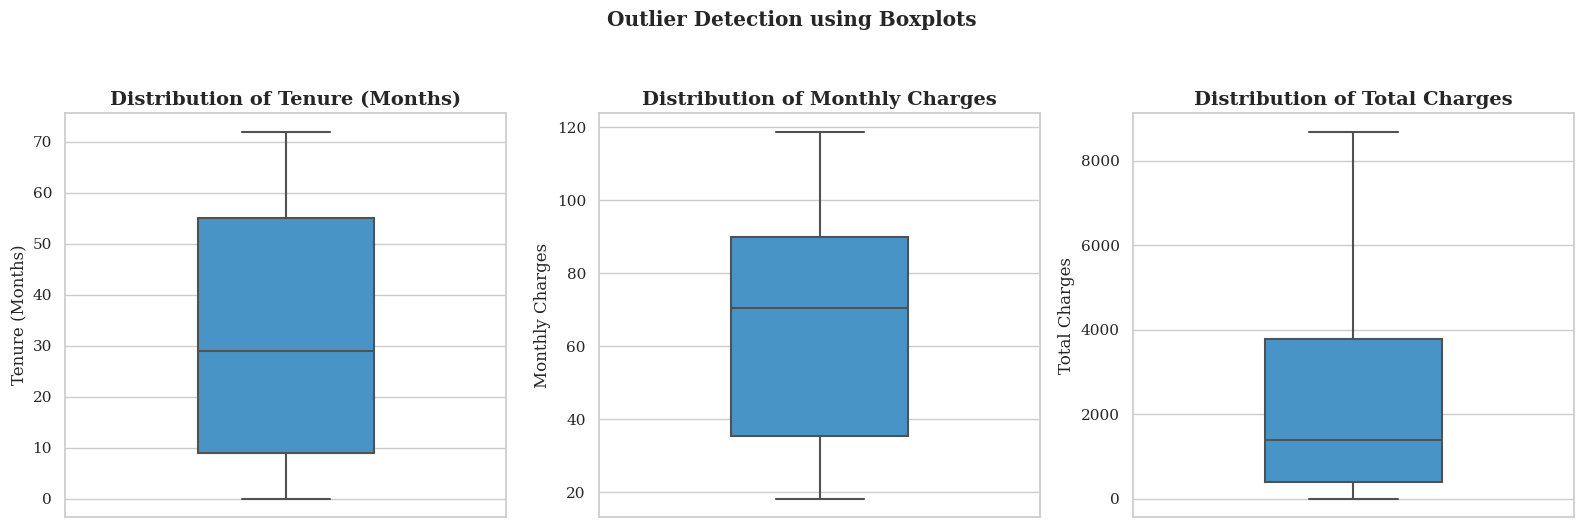

In [15]:
# =========================================================================
# 5. KIỂM TRA NGOẠI LAI (OUTLIERS) BẰNG BOXPLOT
# =========================================================================
print("Đang tiến hành vẽ Boxplot kiểm tra ngoại lai...")

# Danh sách cột số cần check outlier (Sử dụng tên đã được map ở Cell 1)
outlier_features = ['Tenure (Months)', 'Monthly Charges', 'Total Charges']

# Tạo khung hình (Figure) với 3 subplots (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    # Vẽ Boxplot dọc (trục y)
    sns.boxplot(
        y=df[col], 
        ax=axes[i], 
        color='#3498db',   # Xanh dương học thuật, thanh lịch
        width=0.4,
        linewidth=1.5,     # Độ dày viền hộp
        fliersize=4        # Kích thước của các điểm ngoại lai (dấu chấm)
    )
    
    # Cấu hình Tiêu đề và Nhãn bằng Tiếng Anh
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].set_xlabel('') # Bỏ trống trục X vì không cần thiết

# Tiêu đề tổng của toàn bộ biểu đồ
plt.suptitle("Outlier Detection using Boxplots", fontweight='bold', y=1.05)

# Tối ưu layout để không bị đè chữ
plt.tight_layout()

# Lưu hình ảnh chuẩn in ấn LaTeX (dpi=300)
save_path = 'boxplot_outliers.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
print(f"Đã lưu biểu đồ thành công tại: {save_path}")

# Hiển thị đồ thị
plt.show()

Đang tiến hành vẽ KDE Plot và Boxplot...


C:\Users\HGB\AppData\Local\Temp\ipykernel_9240\3273761334.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Đã lưu biểu đồ thành công tại: churn_distribution_analysis.png


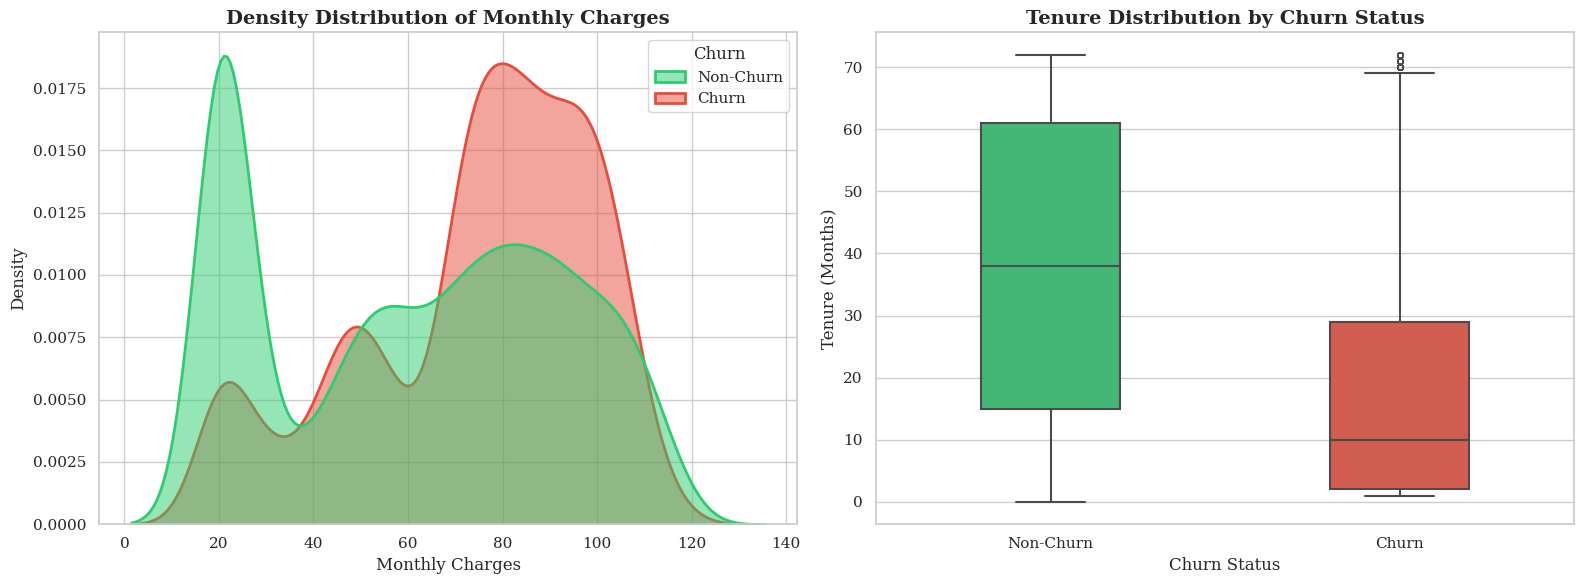

In [16]:
# =========================================================================
# 6. PHÂN TÍCH PHÂN PHỐI BIẾN SỐ THEO NHÓM CHURN (KDE & BOXPLOT)
# =========================================================================
print("Đang tiến hành vẽ KDE Plot và Boxplot...")

# Tạo khung hình với 2 subplots (1 hàng, 2 cột)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Định nghĩa dải màu chuẩn (Đỏ cho Churn, Xanh cho Non-Churn)
churn_palette = {'Churn': '#e74c3c', 'Non-Churn': '#2ecc71'}

# ---------------------------------------------------------
# 1. Vẽ KDE Plot: Phân bố Cước phí hàng tháng
# ---------------------------------------------------------
sns.kdeplot(
    data=df, 
    x='Monthly Charges', # Tên đã được chuẩn hóa ở Cell 1
    hue='Churn', 
    fill=True, 
    common_norm=False, 
    palette=churn_palette, 
    ax=ax[0],
    alpha=0.5,           # Độ trong suốt của màu fill
    linewidth=2          # Độ dày của đường viền KDE
)
ax[0].set_title('Density Distribution of Monthly Charges', fontweight='bold')
ax[0].set_xlabel('Monthly Charges')
ax[0].set_ylabel('Density')

# ---------------------------------------------------------
# 2. Vẽ Boxplot: Thời gian gắn bó (Tenure)
# ---------------------------------------------------------
sns.boxplot(
    data=df, 
    x='Churn', 
    y='Tenure (Months)', # Tên đã được chuẩn hóa ở Cell 1
    palette=churn_palette, 
    ax=ax[1], 
    width=0.4,
    linewidth=1.5,
    fliersize=4
)
ax[1].set_title('Tenure Distribution by Churn Status', fontweight='bold')
ax[1].set_xlabel('Churn Status')
ax[1].set_ylabel('Tenure (Months)')

# Tối ưu khoảng cách layout
plt.tight_layout()

# Lưu hình ảnh chuẩn in ấn LaTeX (dpi=300)
save_path = 'churn_distribution_analysis.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
print(f"Đã lưu biểu đồ thành công tại: {save_path}")

# Hiển thị đồ thị
plt.show()

Đang tiến hành vẽ KDE Plot và Boxplot cho các biến liên tục...


C:\Users\HGB\AppData\Local\Temp\ipykernel_9240\154129357.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\HGB\AppData\Local\Temp\ipykernel_9240\154129357.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\HGB\AppData\Local\Temp\ipykernel_9240\154129357.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Đã lưu biểu đồ thành công tại: continuous_vars_analysis.png


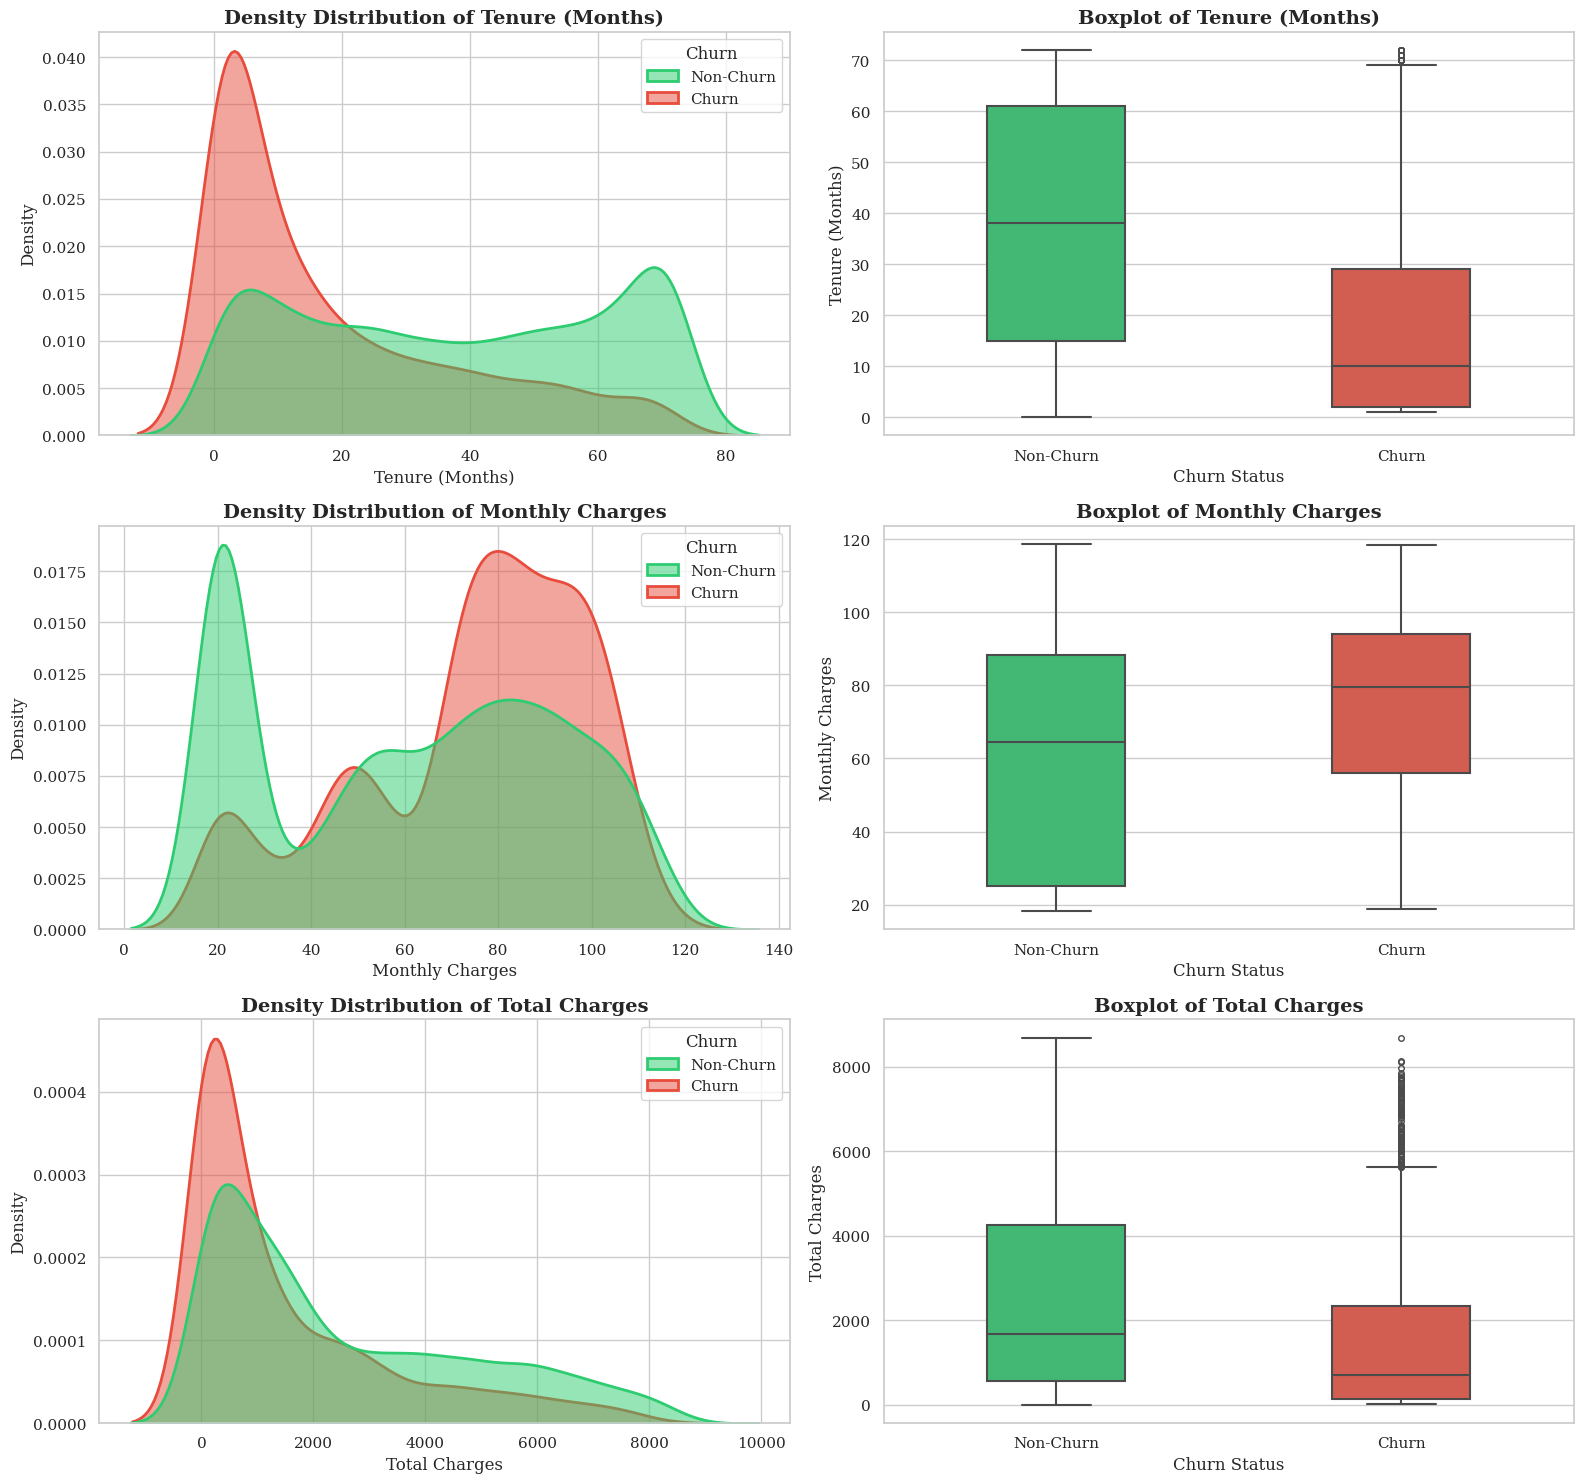

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 7. PHÂN TÍCH CHUYÊN SÂU CÁC BIẾN LIÊN TỤC THEO CHURN
# =========================================================================
print("Đang tiến hành vẽ KDE Plot và Boxplot cho các biến liên tục...")

# Danh sách các biến liên tục (Sử dụng tên đã được map ở Cell 1)
continuous_vars = ['Tenure (Months)', 'Monthly Charges', 'Total Charges']

# Thiết lập khung biểu đồ (grid) với số hàng = số lượng biến, 2 cột
fig, axes = plt.subplots(len(continuous_vars), 2, figsize=(16, 5 * len(continuous_vars)))

# Định nghĩa dải màu chuẩn đồng bộ với các cell trước
churn_palette = {'Churn': '#e74c3c', 'Non-Churn': '#2ecc71'}

for i, col in enumerate(continuous_vars):
    # ---------------------------------------------------------
    # 1. Cột trái: KDE Plot (Mật độ phân phối)
    # ---------------------------------------------------------
    sns.kdeplot(
        data=df, 
        x=col, 
        hue='Churn', 
        fill=True, 
        common_norm=False, 
        palette=churn_palette, 
        ax=axes[i, 0],
        alpha=0.5,       # Làm trong suốt phần fill để dễ nhìn phần giao nhau
        linewidth=2      # Viền nét đậm chuẩn học thuật
    )
    axes[i, 0].set_title(f'Density Distribution of {col}', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Density')
    
    # ---------------------------------------------------------
    # 2. Cột phải: Boxplot (Điểm tập trung & Ngoại lai)
    # ---------------------------------------------------------
    sns.boxplot(
        data=df, 
        x='Churn', 
        y=col, 
        palette=churn_palette, 
        ax=axes[i, 1], 
        width=0.4,
        linewidth=1.5,
        fliersize=4      # Chỉnh kích thước điểm outlier cho tinh tế
    )
    axes[i, 1].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[i, 1].set_xlabel('Churn Status')
    axes[i, 1].set_ylabel(col)

# Tối ưu khoảng cách layout tránh đè chữ
plt.tight_layout()

# Lưu hình ảnh chuẩn in ấn LaTeX (dpi=300)
save_path = 'continuous_vars_analysis.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
print(f"Đã lưu biểu đồ thành công tại: {save_path}")

# Hiển thị đồ thị
plt.show()

Đang tiến hành vẽ Stacked Bar Chart cho tỷ lệ Churn...
Đã lưu biểu đồ thành công tại: stacked_barchart_churn_rate.png


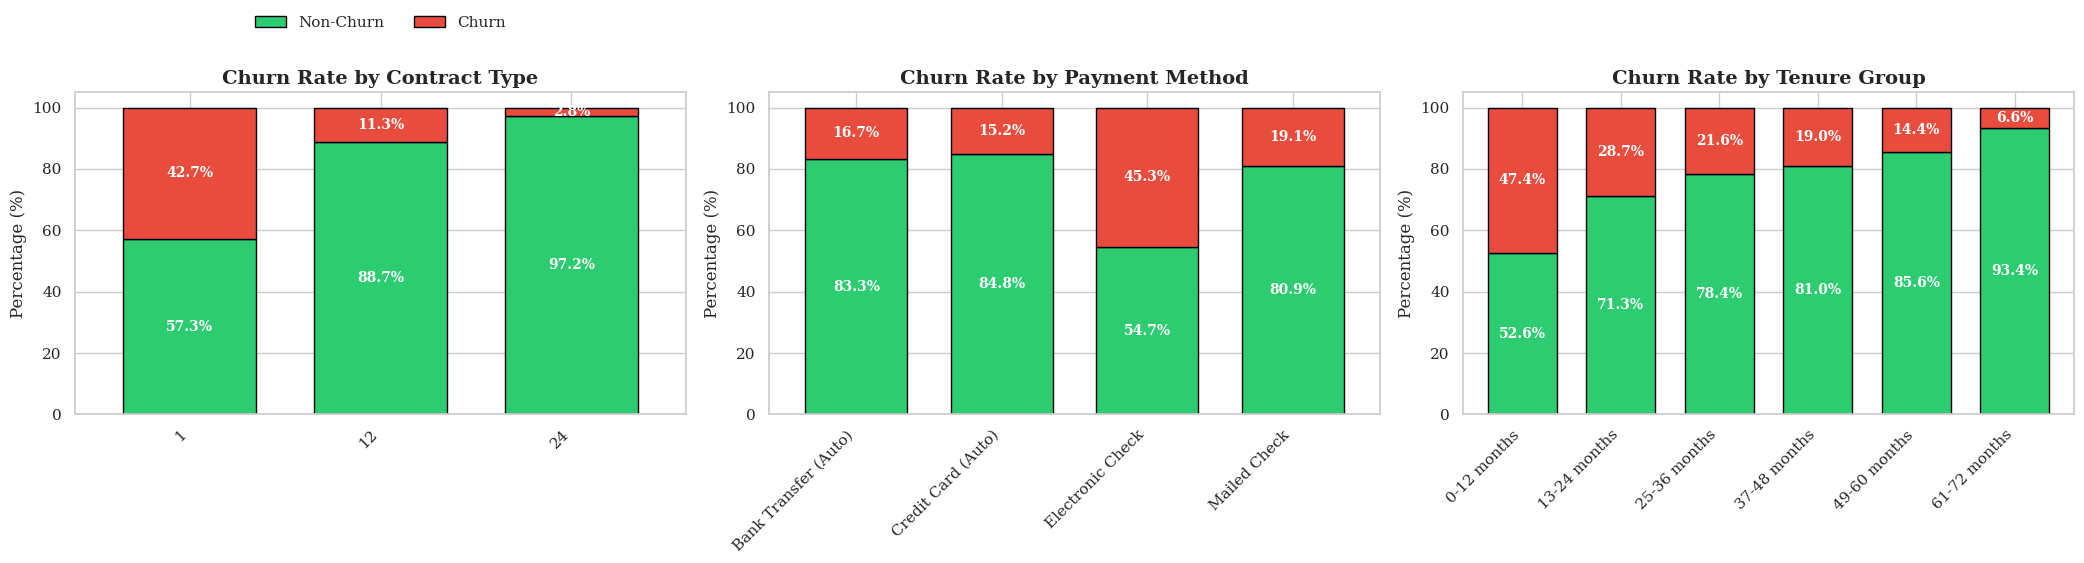

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================================
# 8. PHÂN TÍCH TỶ LỆ CHURN BẰNG BIỂU ĐỒ CỘT CHỒNG (100% STACKED BAR)
# =========================================================================
print("Đang tiến hành vẽ Stacked Bar Chart cho tỷ lệ Churn...")

# Cập nhật danh sách biến phân loại theo tên đã map ở Cell 1
categorical_vars = ['Contract Type', 'Payment Method', 'tenure_group']

# Lọc ra các cột thực sự tồn tại trong df (tránh lỗi nếu chưa chạy Feature Engineering)
cols_to_plot = [col for col in categorical_vars if col in df.columns]

if cols_to_plot:
    fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(7 * len(cols_to_plot), 6))
    
    # Nếu chỉ có 1 biểu đồ thì đưa axes vào list để vòng lặp for không bị lỗi
    if len(cols_to_plot) == 1:
        axes = [axes]

    for i, col in enumerate(cols_to_plot):
        # Tính tỷ lệ % Churn cho từng nhóm
        churn_pct = df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100
        
        # Sắp xếp lại cột để đảm bảo Non-Churn (Xanh) nằm dưới, Churn (Đỏ) nằm trên
        if 'Non-Churn' in churn_pct.columns and 'Churn' in churn_pct.columns:
            churn_pct = churn_pct[['Non-Churn', 'Churn']]
        
        # Vẽ biểu đồ cột chồng 100%
        ax = churn_pct.plot(
            kind='bar', 
            stacked=True, 
            ax=axes[i], 
            color=['#2ecc71', '#e74c3c'],  # Xanh (Non-Churn), Đỏ (Churn)
            edgecolor='black', 
            width=0.7
        )
        
        # Tạo tên hiển thị đẹp cho Title (nếu biến là tenure_group chưa được map)
        display_name = 'Tenure Group' if col == 'tenure_group' else col
        
        # Cấu hình Tiêu đề và Nhãn
        axes[i].set_title(f'Churn Rate by {display_name}', fontweight='bold')
        axes[i].set_ylabel('Percentage (%)')
        axes[i].set_xlabel('')
        
        # Xoay nhãn trục X 45 độ, căn phải để không đè chữ
        axes[i].tick_params(axis='x', rotation=45)
        labels = axes[i].get_xticklabels()
        axes[i].set_xticklabels(labels, rotation=45, ha='right')
        
        # Cấu hình Legend: Đưa lên trên cùng, chia 2 cột, chỉ hiển thị ở đồ thị đầu
        if i == 0:
            axes[i].legend(
                title='', 
                bbox_to_anchor=(0.5, 1.15), 
                loc='lower center', 
                ncol=2, 
                frameon=False
            )
        else:
            axes[i].get_legend().remove()
        
        # Ghi số % trực tiếp lên giữa các khối màu
        for p in axes[i].patches:
            width, height = p.get_width(), p.get_height()
            x, y = p.get_xy() 
            if height > 2:  # Chỉ in số nếu phần trăm > 2% để tránh text đè nhau
                axes[i].text(
                    x + width / 2, 
                    y + height / 2, 
                    f'{height:.1f}%', 
                    ha='center', 
                    va='center', 
                    color='white', 
                    fontweight='bold', 
                    fontsize=10
                )

    # Tối ưu khoảng cách layout
    plt.tight_layout()
    
    # Lưu hình ảnh chuẩn in ấn LaTeX (dpi=300)
    save_path = 'stacked_barchart_churn_rate.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
    print(f"Đã lưu biểu đồ thành công tại: {save_path}")

    plt.show()
else:
    print("Không tìm thấy các cột phân loại trong DataFrame. Vui lòng kiểm tra lại tên cột.")

Đang tiến hành vẽ Grouped Bar Chart...
Đã lưu biểu đồ thành công tại: grouped_barchart_avg_charges.png


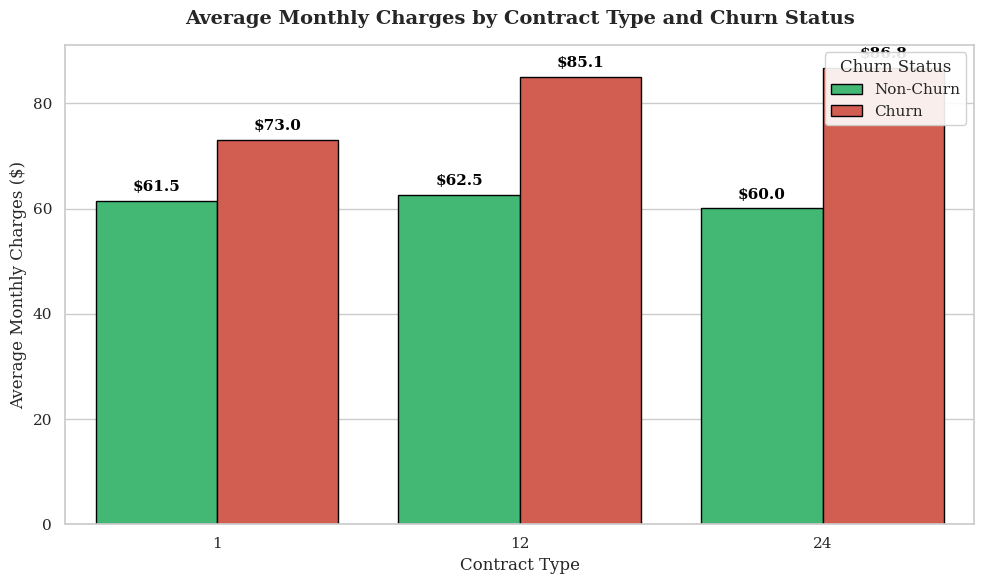

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================================
# 9. VẼ BIỂU ĐỒ CỘT GHÉP (GROUPED BAR CHART) SO SÁNH GIÁ TRỊ TRUNG BÌNH
# =========================================================================
print("Đang tiến hành vẽ Grouped Bar Chart...")

# Tạo khung hình (Figure)
plt.figure(figsize=(10, 6))

# Định nghĩa dải màu chuẩn đã dùng xuyên suốt file
churn_palette = {'Churn': '#e74c3c', 'Non-Churn': '#2ecc71'}

# Vẽ Bar Chart (Mặc định sns.barplot sẽ tính giá trị Trung bình - Mean)
# errorbar=None: Tắt đường kẻ sai số (confidence interval) để biểu đồ gọn gàng hơn
ax = sns.barplot(
    data=df, 
    x='Contract Type',       # Trục X: Biến phân loại (đã map ở Cell 1)
    y='Monthly Charges',     # Trục Y: Biến số cần tính trung bình
    hue='Churn',             # Phân nhóm theo Churn
    palette=churn_palette, 
    edgecolor='black',       # Thêm viền đen mảnh cho cột để sắc nét khi in
    linewidth=1,
    errorbar=None
)

# Cấu hình Tiêu đề và Nhãn chuẩn tiếng Anh
plt.title('Average Monthly Charges by Contract Type and Churn Status', fontweight='bold', pad=15)
plt.xlabel('Contract Type')
plt.ylabel('Average Monthly Charges ($)')

# Ghi giá trị số trực tiếp lên đỉnh của từng cột
for p in ax.patches:
    height = p.get_height()
    # Bỏ qua các cột có chiều cao = 0 (nếu có) để không in số 0.0 thừa
    if height > 0:
        ax.annotate(
            f'${height:.1f}', 
            xy=(p.get_x() + p.get_width() / 2, height),
            xytext=(0, 5),      # Đẩy text lên trên 5 điểm so với đỉnh cột
            textcoords="offset points",
            ha='center', 
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color='black'
        )

# Cấu hình Legend (chỉ lấy 1 legend duy nhất, đặt ở vị trí góc trên)
plt.legend(title='Churn Status', loc='upper right', framealpha=0.9)

# Tối ưu layout
plt.tight_layout()

# Lưu hình ảnh chuẩn in ấn LaTeX (dpi=300)
save_path = 'grouped_barchart_avg_charges.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
print(f"Đã lưu biểu đồ thành công tại: {save_path}")

# Hiển thị đồ thị
plt.show()

Đang tiến hành vẽ Histogram thể hiện phân phối...
Đã lưu biểu đồ thành công tại: histogram_continuous_distributions.png


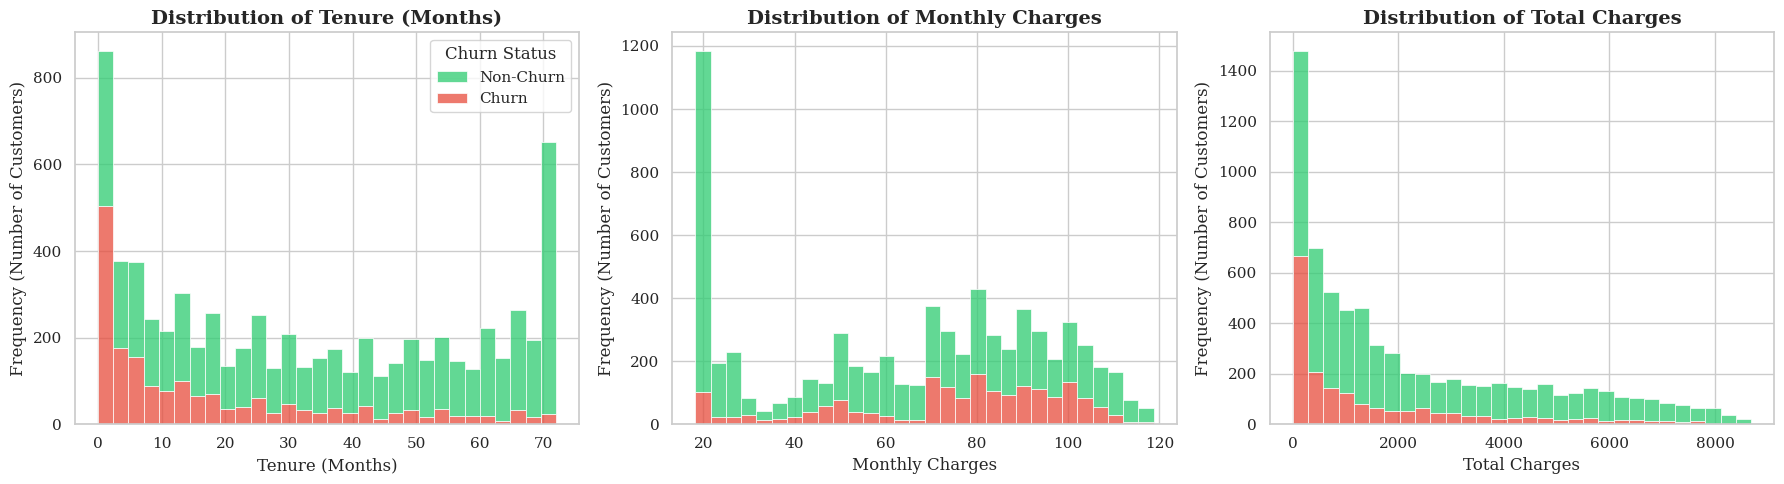

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 10. VẼ HISTOGRAM (PHÂN PHỐI TẦN SUẤT CHO BIẾN LIÊN TỤC)
# =========================================================================
print("Đang tiến hành vẽ Histogram thể hiện phân phối...")

# Cập nhật danh sách biến theo đúng tên đã được chuẩn hóa ở Cell 1
outlier_features = ['Tenure (Months)', 'Monthly Charges', 'Total Charges']

# Tạo khung hình với 3 subplots (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

# Dải màu đồng bộ
churn_palette = {'Churn': '#e74c3c', 'Non-Churn': '#2ecc71'}

for i, col in enumerate(outlier_features):
    # Vẽ Histogram (chia dữ liệu thành 30 cột/bins)
    sns.histplot(
        data=df, 
        x=col, 
        hue='Churn', 
        multiple='stack',    # Xếp chồng 2 nhóm (Churn/Non-Churn) lên nhau để xem tổng thể
        bins=30,             # Số lượng cột chia ra (có thể tùy chỉnh)
        palette=churn_palette, 
        edgecolor='white',   # Viền trắng mảnh giúp phân tách các cột rõ nét hơn
        linewidth=0.5,
        ax=axes[i]
    )
    
    # Cấu hình Tiêu đề và Nhãn chuẩn Tiếng Anh
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency (Number of Customers)')
    
    # Cấu hình Legend (chỉ giữ ở đồ thị đầu tiên)
    if i == 0:
        sns.move_legend(axes[i], "upper right", title='Churn Status')
    else:
        # sns.histplot đôi khi không tạo legend nếu không cần thiết, dùng try-except để gỡ an toàn
        if axes[i].get_legend() is not None:
            axes[i].get_legend().remove()

# Tối ưu khoảng cách layout
plt.tight_layout()

# Lưu hình ảnh chuẩn in ấn LaTeX (dpi=300)
save_path = 'histogram_continuous_distributions.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')
print(f"Đã lưu biểu đồ thành công tại: {save_path}")

# Hiển thị đồ thị
plt.show()